In [1]:
import os
import sys
sys.path.append("../..")

import dill as pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.distributions as td
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric as pyg
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool
from torch_geometric.datasets import TUDataset

from egg_models import egg_generic_losses
from egg_models.egg_generic import EggGeneric
from egg_models.egg_generic import EggGeneric
from functools import partial
from matplotlib.patches import ConnectionPatch
from scipy.stats import gaussian_kde, t
from sklearn.metrics import confusion_matrix

from utils import mutag_helper
from utils import visuals
import pygmtools as pygm
import networkx as nx

from egg_models.egg_generic_losses import activation_hook, dict_cos_dist, GEDasMatchLoss
from scipy.stats import stats

2024-10-30 20:07:32.489009: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-30 20:07:50.569244: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Reproducibility
SEED = 123123
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True 
np.random.seed(SEED)

#Meta-Data
device = torch.device(0)
node_types = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']
edge_types = ['aromatic', 'single', 'double', 'triple']
color_palette = np.array(['orange', 'magenta', 'green', 'blue', 'cyan', 'red', 'lime'])
color_palette_dropped = np.array(['orange', 'magenta', 'green', 'blue', 'red'])

# Data Prep

## Helper Functions

In [3]:
# Explainee Model
class GCN(torch.nn.Module):
    def __init__(self, node_features, hc1=64, hc2=32, hc3=16):
        super().__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(node_features, hc1)
        self.conv2 = GCNConv(hc1, hc2)
        self.conv3 = GCNConv(hc2, hc3)
        self.lin = nn.Linear(hc3, 2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # 1. Obtain node embeddings 
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        
        return x

In [4]:
def train_explainee(
    explainee: nn.Module,
    train_data: list, 
    test_data: list, 
    ):

    train_data_loader = pyg.loader.DataLoader(train_data, 
                                            batch_size=16, shuffle=True)
    test_data_loader = pyg.loader.DataLoader(test_data, 
                                            batch_size=16, shuffle=False)

    optimizer = torch.optim.Adam(explainee.parameters(), lr=0.001)
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(201): 
        explainee.train()        
        for batch in train_data_loader: 
            out = explainee(batch)
            loss = criterion(out, batch.y)
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

        explainee.eval()
        correct = 0
        for batch in train_data_loader: 
            out = explainee(batch)
            pred = out.argmax(dim=1)
            correct += int((pred == batch.y).sum())

        train_accuracy = correct / len(train_data_loader.dataset)

        correct = 0
        for batch in test_data_loader: 
            out = explainee(batch)
            pred = out.argmax(dim=1)
            correct += int((pred == batch.y).sum())

        test_accuracy = correct / len(test_data_loader.dataset)

        print(f"Epoch: {epoch} Train Accuracy: {train_accuracy} " + 
            f"Test Accuracy: {test_accuracy}")


    full_batch = pyg.data.Batch.from_data_list(test_data)
    explainee.eval()
    preds = explainee(full_batch).argmax(dim=1).numpy()
    targets = full_batch.y.numpy()

    conf_matrix = confusion_matrix(targets, preds)
    print(conf_matrix)

    return explainee

In [5]:
def extract_embeddings(
    explainee: nn.Module, 
    train_data: list, 
    ):

    activation_names = ["conv1", "conv2", "conv3"]
    train_avg_embedding_0 = {"conv1": [], "conv2": [], "conv3": []}
    train_avg_embedding_1 = {"conv1": [], "conv2": [], "conv3": []}
    pool_func = pyg.nn.global_mean_pool


    train_data_loader = pyg.loader.DataLoader(train_data)
    for batch in train_data_loader:
        explainee.eval()

        acts, remove_hooks = activation_hook(explainee, activation_names)
        out = explainee(batch)
        remove_hooks()

        if batch.y.item() == 0: 
            for name in activation_names: 
                embed = pool_func(acts[name], batch.batch)
                train_avg_embedding_0[name].append(
                    embed.detach().to('cpu')
                )

        if batch.y.item() == 1: 
            for name in activation_names: 
                embed = pool_func(acts[name], batch.batch)
                train_avg_embedding_1[name].append(
                    embed.detach().to('cpu')
                )
                
    for name in activation_names:
        train_avg_embedding_0[name] = torch.stack(
            train_avg_embedding_0[name]
        ).mean(dim=0)

        train_avg_embedding_1[name] = torch.stack(
            train_avg_embedding_1[name]
        ).mean(dim=0)

    return train_avg_embedding_0, train_avg_embedding_1

## Raw Data

In [6]:
# Raw data

# Download data. 
data_raw = TUDataset(root='data/TUDataset', name='MUTAG')

# Shuffle
data_raw = data_raw.shuffle()

# Split 
train_data = data_raw[:150]
test_data = data_raw[150:]

# Create data lists
train_data_list = []
train_data_list_0 = []
train_data_list_1 = []
test_data_list = []
test_data_list_0 = []
test_data_list_1 = []

for graph in train_data:
    train_data_list.append(graph)

    if graph.y.item() == 0: 
        train_data_list_0.append(graph)

    elif graph.y.item() == 1: 
        train_data_list_1.append(graph)

for graph in test_data:
    test_data_list.append(graph)

    if graph.y.item() == 0: 
        test_data_list_0.append(graph)

    elif graph.y.item() == 1: 
        test_data_list_1.append(graph)

In [7]:
explainee_raw = train_explainee(
    GCN(node_features=7), 
    train_data_list, test_data_list
)

Epoch: 0 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 1 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 2 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 3 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 4 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 5 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 6 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 7 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 8 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 9 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 10 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 11 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 12 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.

In [8]:
train_avg_embedding_0, train_avg_embedding_1 = extract_embeddings(
    explainee_raw, train_data_list
)
print(train_avg_embedding_0)
print(train_avg_embedding_1)

{'conv1': tensor([[-2.5616e-02,  3.5865e-02,  2.2708e-02, -6.0919e-02,  1.1478e-01,
         -5.7976e-02,  1.5329e-01, -5.8544e-02,  3.1236e-01,  7.9226e-03,
         -1.5723e-01,  7.3637e-02,  5.1356e-03, -8.6245e-02, -1.9665e-01,
         -4.6060e-03, -2.4553e-02,  2.6134e-03,  8.7952e-05, -1.6012e-01,
         -3.5422e-02,  1.2097e-01,  7.3860e-02, -1.3997e-01,  1.7250e-02,
          2.4613e-02, -6.1222e-02,  1.6407e-01, -3.2518e-01,  1.7116e-01,
         -3.1727e-02, -1.1589e-01,  4.7401e-03, -1.2909e-01,  7.1675e-02,
         -4.0509e-02, -7.7566e-02,  5.2777e-02, -4.0029e-03,  1.4338e-01,
         -6.6134e-02,  1.6166e-02,  4.7563e-02, -3.2336e-02, -4.8085e-02,
         -1.2039e-01, -1.2067e-01,  5.8204e-02, -6.6188e-03,  2.4483e-03,
          1.2473e-02,  7.1323e-02, -2.3756e-02, -1.6651e-01,  1.5828e-02,
          4.1388e-02, -8.7087e-02,  7.0760e-04, -6.4389e-02, -2.5253e-04,
         -3.3731e-02,  6.5148e-03,  1.2479e-01, -9.7723e-02]]), 'conv2': tensor([[-0.0645, -0.0451,  0

## Dropped

In [9]:
data_dropped = []

for graph in data_raw:
    node_types = graph.x.argmax(dim=-1)
    edge_types = graph.edge_attr.argmax(dim=-1)

    if torch.any(node_types == 4) or torch.any(node_types == 6) or torch.any(edge_types == 3): 
        print(graph) 
    else: 
        graph.x = torch.cat([graph.x[:, :4], graph.x[:, 5].unsqueeze(1)], dim=1)
        graph.edge_attr = graph.edge_attr[:, :3]
        data_dropped.append(graph)

data_dropped[1]

Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])
Data(edge_index=[2, 28], x=[14, 7], edge_attr=[28, 4], y=[1])
Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])
Data(edge_index=[2, 40], x=[18, 7], edge_attr=[40, 4], y=[1])


Data(edge_index=[2, 38], x=[17, 5], edge_attr=[38, 3], y=[1])

In [10]:
# Split 
train_data_dropped = data_dropped[:150]
test_data_dropped = data_dropped[150:]

# Create data lists
train_data_list_dropped = []
train_data_list_dropped_0 = []
train_data_list_dropped_1 = []
test_data_list_dropped = []
test_data_list_dropped_0 = []
test_data_list_dropped_1 = []

for graph in train_data_dropped:
    train_data_list_dropped.append(graph)

    if graph.y.item() == 0: 
        train_data_list_dropped_0.append(graph)

    elif graph.y.item() == 1: 
        train_data_list_dropped_1.append(graph)

for graph in test_data_dropped:
    test_data_list_dropped.append(graph)

    if graph.y.item() == 0: 
        test_data_list_dropped_0.append(graph)

    elif graph.y.item() == 1: 
        test_data_list_dropped_1.append(graph)

In [11]:
explainee_dropped = train_explainee(
    GCN(node_features=5), 
    train_data_list_dropped, 
    test_data_list_dropped
)  

Epoch: 0 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 1 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 2 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 3 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 4 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 5 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 6 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 7 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 8 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 9 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 10 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 11 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 12 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.

In [12]:
train_avg_embedding_0_dropped, train_avg_embedding_1_dropped = extract_embeddings(
    explainee_dropped, train_data_list_dropped
)
print(train_avg_embedding_0_dropped)
print(train_avg_embedding_1_dropped)

{'conv1': tensor([[-0.0276,  0.0798,  0.1924,  0.1729, -0.0075,  0.1216,  0.0237,  0.1757,
          0.1126, -0.0739, -0.0710, -0.0031, -0.0275, -0.0070,  0.0217, -0.0237,
          0.0092,  0.0541, -0.0590,  0.0186, -0.1923, -0.0211,  0.1099,  0.0057,
         -0.0199, -0.0091,  0.1507,  0.0507, -0.0247,  0.0169,  0.0005,  0.1497,
          0.0133,  0.0581,  0.1614, -0.0114, -0.0009, -0.0009, -0.0342,  0.0246,
         -0.0813, -0.0117,  0.0851, -0.1581, -0.0043, -0.2818,  0.1122,  0.0074,
          0.1568,  0.0783, -0.0099,  0.0165,  0.0343,  0.1089, -0.0192,  0.1614,
         -0.0093,  0.1375,  0.0141,  0.0689,  0.1716, -0.0262,  0.0517,  0.0913]]), 'conv2': tensor([[-0.1885,  0.1674,  0.1749, -0.1000,  0.0770,  0.1459,  0.2849,  0.1932,
         -0.0510,  0.0812, -0.1993, -0.2232,  0.1412, -0.2686, -0.2893, -0.2965,
         -0.2149, -0.1909, -0.0599, -0.2064, -0.1401,  0.1115,  0.1477, -0.0557,
          0.1658,  0.2561,  0.1316, -0.1155, -0.1595, -0.1507,  0.1499,  0.1483]]), 'co

# EGG

## Helper Functions

In [13]:
def t_confidence_interval(data):
    mean = np.mean(data)
    std_dev = np.std(data)

    print(f"Mean {mean} SD: {std_dev}")

    n = len(data)
    t_value = t.ppf(0.975, df=n-1) 
    margin_of_error = t_value * (std_dev / np.sqrt(n))
    lower_bound = np.round(mean - margin_of_error, 4)
    upper_bound = np.round(mean + margin_of_error, 4)

    print(f"({lower_bound}, {upper_bound})")

In [14]:
def pre_acc_interval(
    generator: nn.Module, 
    explainee: nn.Module, 
    target
    ):
    generator.eval()
    explainee.eval()

    pred_acc = []
    for i in range(1000):
        with torch.no_grad():
            gen_ex = mutag_helper.egg_to_ex(generator())
            pred = torch.softmax(explainee(gen_ex), dim=-1).mean(dim=0)
            pred_acc.append(pred[target].item())
    
    t_confidence_interval(pred_acc)

In [15]:
def GED_interval(
    generator: nn.Module, 
    GED_fn: nn.Module, 
    data_list: list, 
    batch_size=16, 
    ):
    generator.eval()
    loader = pyg.loader.DataLoader(data_list, 
                                   batch_size=batch_size, drop_last=True)
    running_GED = []
    for batch in loader:
        batch = batch.to(device)
        with torch.no_grad():
            generated = generator()
            gen_ex = mutag_helper.egg_to_ex(generated)
            gen_egg = mutag_helper.egg_to_egg(generated)
            obs_egg = mutag_helper.ex_to_egg(batch)

            egg_sizes = torch.tensor([
                graph.x.shape[0] + graph.edge_index.shape[1] 
                for graph in gen_ex.to_data_list()
            ]).to(device)

            loss = (
                GED_fn(*gen_egg, *obs_egg) / 
                egg_sizes
            ).mean()

            running_GED.append(min(loss.item(), 1.0))

    t_confidence_interval(running_GED)

In [16]:
def train_egg(
    dis_node_feats: int, 
    dis_edge_feats: int, 
    explainee: nn.Module, 
    target: int, 
    train_data_list_1, 
    train_data_list_0, 
    train_data_list_full, 
    pred_loss_embeds, 
    other_class_embeds,  
    max_node_size=20, 
    temp=0.15, 
    epochs=25, 
    loss_fn_weights=torch.tensor([1.0, 1.0, 1.0, 1.0]), 
    use_egg_size=False, 
    use_omega=True,  
    batch_size=16
    ):
    # Define target tensors. 
    if target == 1:
        target_tensor = torch.tensor([0.0, 1.0])
    else: 
        target_tensor = torch.tensor([1.0, 0.0])

    # Setup explainee. 
    explainee.eval()
    explainee.to(device)

    # Define generator to train. 
    generator = EggGeneric(
        max_node_size=max_node_size,
        cont_node_feats=None, 
        cont_edge_feats=None, 
        dis_node_feats=(dis_node_feats, ), 
        dis_edge_feats=(dis_edge_feats, ), 
        temp=temp, 
        batch_size=batch_size, 
    )
    generator.to(device)

    # Define GED function.
    GED_fn = egg_generic_losses.GEDasMatchLoss(
        node_size=max_node_size, 
        cont_node_indices=None, 
        cont_edge_indices=None, 
        dis_node_indices=(slice(0, dis_node_feats), ),  
        dis_edge_indices=(slice(0, dis_edge_feats), dis_edge_feats), 
        QAP_solver=pygm.ngm, 
    )

    # Compute random baseline.
    print("Baseline Prediction Accuracy: ")
    pre_acc_interval(generator, explainee, target)
    print(f"Baseline % GED to 1")
    GED_interval(generator, GED_fn, train_data_list_1)
    print(f"Baseline % GED to 0")
    GED_interval(generator, GED_fn, train_data_list_0)

    # Train EGG model.
    train_loader = pyg.loader.DataLoader(train_data_list_full, 
                                         batch_size=batch_size, drop_last=True)
    pred_loss_fn = egg_generic_losses.PredLossBatched(
        target_tensor, explainee, avg_embed_targets=pred_loss_embeds
    )
    embed_dist_fn = egg_generic_losses.EmbDistGeneric(
        explainee, avg_embed_targets=other_class_embeds
    )
    edge_pen_fn = egg_generic_losses.EdgePenalty(edge_budget = 10)
    generator.train()
    optimizer = torch.optim.RMSprop(generator.parameters()) 
    for epoch in range(epochs):
        report_loss = np.array([0.0, 0.0, 0.0, 0.0])
        for obs_batch in train_loader: 
            optimizer.zero_grad()
            obs_batch = obs_batch.to(device)
            gen_graph = generator()

            # Data formatting. 
            gen_ex = mutag_helper.egg_to_ex(gen_graph) 
            gen_egg = mutag_helper.egg_to_egg(gen_graph)
            obs_egg = mutag_helper.ex_to_egg(obs_batch)

            loss_1, _, _ = pred_loss_fn(gen_ex)
            loss_1 = loss_1.mean()

            loss_embed = -1 * embed_dist_fn(gen_ex).mean()

            #loss_edge = torch.sum(generator.AdjacencyMatrix.probs, dim=0).mean()
            loss_edge = edge_pen_fn(generator.AdjacencyMatrix.probs)

            loss_2 = GED_fn(*gen_egg, *obs_egg)
            if use_egg_size:
                egg_size = torch.tensor([
                    graph.x.shape[0] + graph.edge_index.shape[1] 
                    for graph in gen_ex.to_data_list()
                ]).to(loss_2.device)
            else: 
                egg_size = 1.0
            
            if use_omega:
                with torch.no_grad():
                    explainee_pred = F.softmax(explainee(obs_batch), dim=-1)
                    omega = (explainee_pred @ 
                        target_tensor.to(explainee_pred.device) - 0.5
                    )
            else:
                omega = 1
            loss_3 = (omega * loss_2 / egg_size).mean()

            report_loss += [loss_1.item(), loss_embed.item(), 
                            loss_edge.item(), loss_3.item()]
            report_loss
            loss = (
                loss_fn_weights.to(loss_1.device) @ 
                torch.stack((loss_1, loss_embed, loss_edge, loss_3)) 
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)

            optimizer.step() 

        report_loss = [x / len(train_loader) for x in report_loss]
        print(f"Epoch: {epoch} Losses:{report_loss}")

    print("Trained Prediction Accuracy: ")
    pre_acc_interval(generator, explainee, target)
    print(f"Trained % GED to 1")
    GED_interval(generator, GED_fn, train_data_list_1)
    print(f"Trained % GED to 0")
    GED_interval(generator, GED_fn, train_data_list_0)

    return generator 

In [17]:
# Visualize Connected Graph
def vis_con_graph(
    generator: nn.Module, 
    explainee: nn.Module, 
    dis_node_feats: int, 
    dis_edge_feats: int, 
    target: int, 
    obs_ex1, 
    obs_ex2, 
    color_palette=color_palette
    ):

    generator_batch_1 = EggGeneric(
        max_node_size=generator.max_node_size,
        cont_node_feats=None, 
        cont_edge_feats=None, 
        dis_node_feats=(dis_node_feats, ), 
        dis_edge_feats=(dis_edge_feats, ), 
        temp=generator.temp, 
        batch_size=1, 
    )
    generator_batch_1.load_state_dict(generator.state_dict())
    generator_batch_1.to(device)

    # Define GED function.
    GED_fn = egg_generic_losses.GEDasMatchLoss(
        node_size=generator.max_node_size, 
        cont_node_indices=None, 
        cont_edge_indices=None, 
        dis_node_indices=(slice(0, dis_node_feats), ),  
        dis_edge_indices=(slice(0, dis_edge_feats), dis_edge_feats), 
        QAP_solver=pygm.ngm, 
    )

    gen = generator_batch_1()
    gen_ex = mutag_helper.egg_to_ex(gen)
    gen_egg = mutag_helper.egg_to_egg(gen)
    colors0 = color_palette[torch.argmax(gen_ex.x, dim=-1).cpu().numpy()]
    gen_nx = pyg.utils.to_networkx(gen_ex)

    obs_ex1 = obs_ex1.to(device)
    obs_egg1 = mutag_helper.ex_to_egg(pyg.data.Batch().from_data_list([obs_ex1]))
    colors1 = color_palette[torch.argmax(obs_ex1.x, dim=-1).cpu().numpy()]
    obs_nx = pyg.utils.to_networkx(obs_ex1)

    obs_ex2 = obs_ex2.to(device)
    obs_egg2 = mutag_helper.ex_to_egg(pyg.data.Batch().from_data_list([obs_ex2]))
    colors2 = color_palette[torch.argmax(obs_ex2.x, dim=-1).cpu().numpy()]
    obs_nx2 = pyg.utils.to_networkx(obs_ex2)

    with torch.no_grad():
        aff_mat = GED_fn.get_aff_mat(*gen_egg, *obs_egg1)
        dis_match_mat = GED_fn.get_dis_match_mat(aff_mat)

    with torch.no_grad():
        aff_mat2 = GED_fn.get_aff_mat(*gen_egg, *obs_egg2)
        dis_match_mat2 = GED_fn.get_dis_match_mat(aff_mat2)

    egg_size = torch.tensor([
        graph.x.shape[0] + graph.edge_index.shape[1] 
        for graph in gen_ex.to_data_list()
    ]).to(device)

    GED_score1 = (
        -1 * pygm.utils.compute_affinity_score(dis_match_mat, aff_mat) / 
        egg_size
    ).item()
    GED_score1 = min(GED_score1, 1.0) # cap at 100% edit.

    GED_score2 = (
        -1 * pygm.utils.compute_affinity_score(dis_match_mat2, aff_mat2) / 
        egg_size
    ).item()
    GED_score2 = min(GED_score2, 1.0)


    pos_1 = nx.spring_layout(obs_nx)
    # pos_2 = nx.spring_layout(gen_nx)
    pos_2 = {}
    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat.squeeze()[i]).item()
        pos_2[i] = pos_1[j]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

    nx.draw(obs_nx, node_color = colors1, pos = pos_1, ax=axes[0])

    nx.draw(gen_nx, node_color = colors0, pos=pos_2, ax=axes[1])

    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat.squeeze()[i]).item()
        con = ConnectionPatch(xyA=pos_2[i], xyB=pos_1[j], 
                            coordsA="data", coordsB="data",
                            axesA=axes[0], axesB=axes[1], color="green")

        fig.add_artist(con)

    pos_3 = nx.spring_layout(obs_nx2)
    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat2.squeeze()[i]).item()
        pos_3[j] = pos_2[i]

    nx.draw(obs_nx2, node_color = colors2, pos = pos_3, ax=axes[2])

    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat2.squeeze()[i]).item()
        con = ConnectionPatch(xyA=pos_3[j], xyB=pos_2[i], 
                            coordsA="data", coordsB="data",
                            axesA=axes[2], axesB=axes[1], color="blue")

        fig.add_artist(con)

    explainee.eval()
    with torch.no_grad():
        pred_gen = torch.softmax(explainee(gen_ex), -1)[:, target].item()
        pred_obs1 = torch.softmax(explainee(obs_ex1), -1)[:, target].item()
        pred_obs2 = torch.softmax(explainee(obs_ex2), -1)[:, target].item()

    axes[0].set_title(f"Class Probability: {pred_obs1:0.2f} GED: {GED_score1:0.2f}")
    axes[1].set_title(f"Class Probability: {pred_gen:0.2f}")
    axes[2].set_title(f"GED: {GED_score2:0.2f} Class Probability: {pred_obs2:0.2f}")

# Results

## Re-implementationn of GNNInterpreter

In [18]:
gen_gnnInt_1 = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.043840380366775206 SD: 0.03668288951679185
(0.0416, 0.0461)
Baseline % GED to 1
Mean 0.09228774373020444 SD: 0.0030933700711587445
(0.0894, 0.0951)
Baseline % GED to 0
Mean 0.07689097275336583 SD: 0.00521944878451968
(0.0714, 0.0824)
Epoch: 0 Losses:[2.2827872146259653, -0.5913877839391882, 10672.058083274147, 2.6240756620060313]
Epoch: 1 Losses:[1.3008886792443015, -1.2357848503372886, 2425.700051047585, 2.7652806260369043]
Epoch: 2 Losses:[0.9476249326359142, -1.4926214109767566, 939.8886274857955, 2.8020725466988305]
Epoch: 3 Losses:[0.8706487525593151, -1.554132721640847, 344.89483642578125, 2.916072888807817]
Epoch: 4 Losses:[0.608880796215751, -1.7341217777945779, 127.86512340198864, 2.9485879269513218]
Epoch: 5 Losses:[0.6303879889574918, -1.7240408875725486, 50.7707554210316, 2.9001984162764116]
Epoch: 6 Losses:[0.6377981061285193, -1.7171250690113415, 21.88923593000932, 2.9923953034661035]
Epoch: 7 Losses:[0.5632912570779974, -1.7809596386

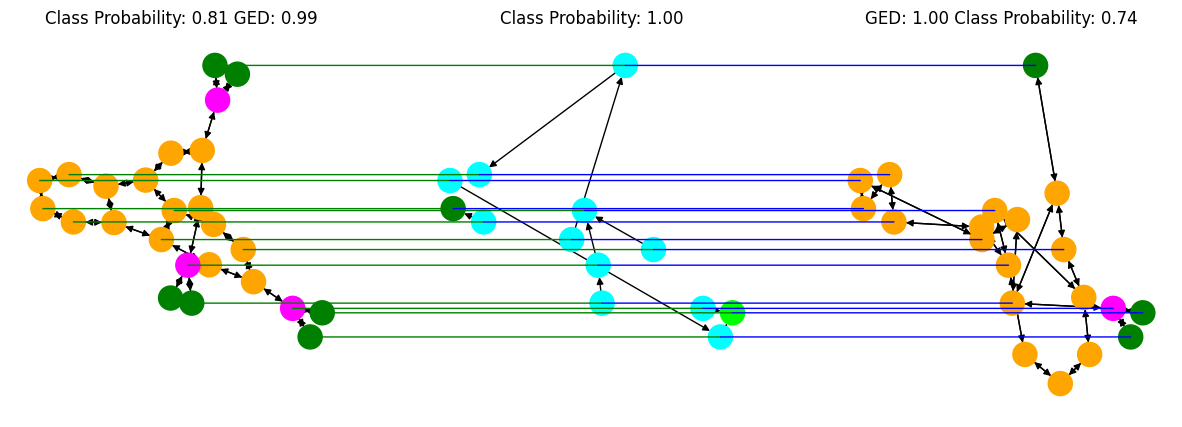

In [19]:
vis_con_graph(
    gen_gnnInt_1, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [20]:
gen_gnnInt_0 = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.8924885150790215 SD: 0.06104002026246029
(0.8887, 0.8963)
Baseline % GED to 1
Mean 0.08490536042622157 SD: 0.001690902289113405
(0.0833, 0.0865)
Baseline % GED to 0
Mean 0.07010656346877416 SD: 0.004287942835785634
(0.0656, 0.0746)
Epoch: 0 Losses:[0.4672124981880188, -1.823672272942283, 12879.026189630682, -2.607030846855857]
Epoch: 1 Losses:[0.43001525510441174, -1.8484500321474941, 2073.196610884233, -2.785748741843484]
Epoch: 2 Losses:[0.44987462867390027, -1.835540316321633, 671.4723427512429, -2.8797812786969272]
Epoch: 3 Losses:[0.439661370082335, -1.8392944986169988, 265.42270591042256, -2.942942976951599]
Epoch: 4 Losses:[0.42287731170654297, -1.856625957922502, 110.87781663374467, -2.981729128144004]
Epoch: 5 Losses:[0.3940864259546453, -1.8715230226516724, 49.17728042602539, -2.921674468300559]
Epoch: 6 Losses:[0.38395008173855866, -1.8780730746009133, 23.221921227195047, -2.9224300492893565]
Epoch: 7 Losses:[0.40920695662498474, -1.8594

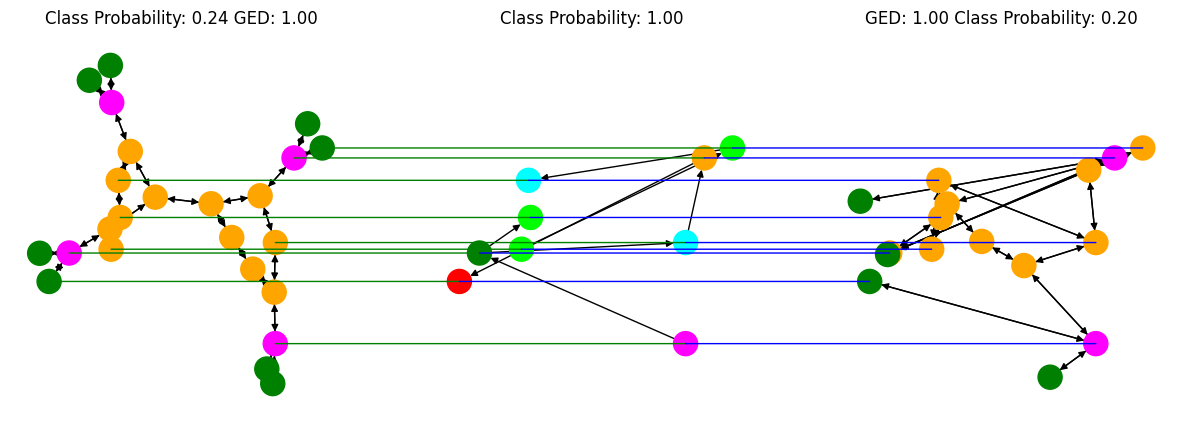

In [21]:
vis_con_graph(
    gen_gnnInt_0,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[2].clone(), 
    obs_ex2=test_data_list_0[3].clone(), 
    target=0
)

In [22]:
gen_gnnInt_1_dropped = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.015887616303982215 SD: 0.013828971960052769
(0.015, 0.0167)
Baseline % GED to 1
Mean 0.08320752531290054 SD: 0.0015122934596012176
(0.0818, 0.0846)
Baseline % GED to 0
Mean 0.06562049314379692 SD: 0.003939496578442934
(0.0615, 0.0698)
Epoch: 0 Losses:[3.003972985527732, -0.09061149101365697, 12797.25106534091, 2.7346044778823853]
Epoch: 1 Losses:[2.924743348901922, -0.11564502492547035, 2100.522449840199, 2.843430378220298]
Epoch: 2 Losses:[3.0137641429901123, -0.07361027259718288, 637.5247275612571, 2.9376142891970547]
Epoch: 3 Losses:[3.0664358789270576, -0.06386622820388187, 234.8061065673828, 2.933740258216858]
Epoch: 4 Losses:[3.0969373746351763, -0.05224525386636907, 98.32725247469816, 2.993280042301525]
Epoch: 5 Losses:[3.103951779278842, -0.050505388866771354, 42.8849026073109, 2.951201644810763]
Epoch: 6 Losses:[3.082639520818537, -0.06345311924815178, 19.738657084378328, 2.983516671440818]
Epoch: 7 Losses:[3.0918844396417793, -0.057957306

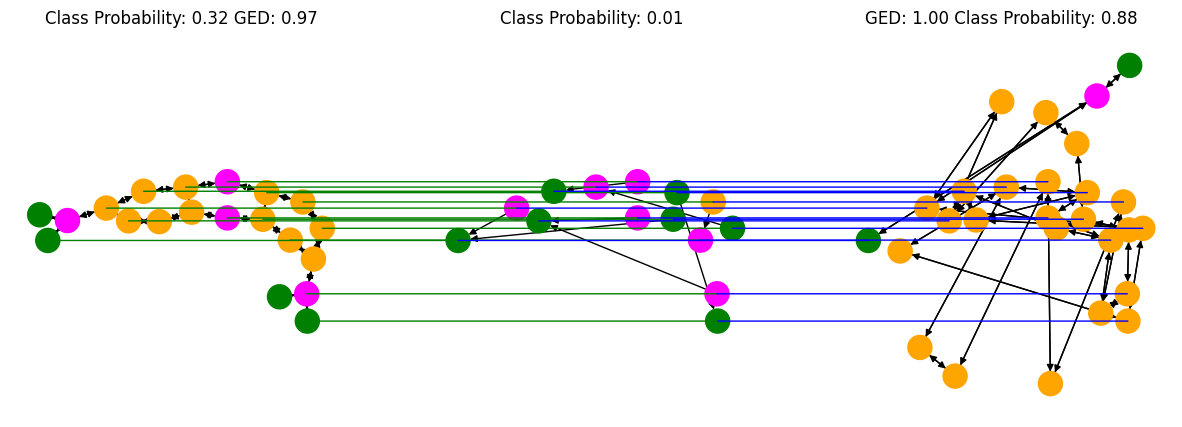

In [23]:
vis_con_graph(
    gen_gnnInt_1_dropped, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[1].clone(), 
    obs_ex2=test_data_list_dropped_1[5].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [24]:
gen_gnnInt_0_dropped = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.9944215025901795 SD: 0.007782442198555737
(0.9939, 0.9949)
Baseline % GED to 1
Mean 0.07821039048333962 SD: 0.0026317803390251545
(0.0765, 0.0799)
Baseline % GED to 0
Mean 0.06788123399019241 SD: 0.0010555300774369334
(0.0653, 0.0705)
Epoch: 0 Losses:[0.38194727355783636, -1.8628091161901301, 11917.831853693182, -2.4967497370459815]
Epoch: 1 Losses:[0.376347926529971, -1.8655665896155618, 2024.5123512961648, -2.598822469061071]
Epoch: 2 Losses:[0.37580647522752936, -1.8652619990435513, 654.2056857022372, -2.671697670763189]
Epoch: 3 Losses:[0.37458355047486047, -1.8636990893970837, 251.3163396661932, -2.674554152922197]
Epoch: 4 Losses:[0.37407771294767206, -1.862132115797563, 105.56866524436258, -2.5628361810337412]
Epoch: 5 Losses:[0.37358721548860724, -1.857978105545044, 45.48205375671387, -2.561787171797319]
Epoch: 6 Losses:[0.375302946025675, -1.850279992276972, 20.465584234757856, -2.53311008756811]
Epoch: 7 Losses:[0.3737338727170771, -1.852

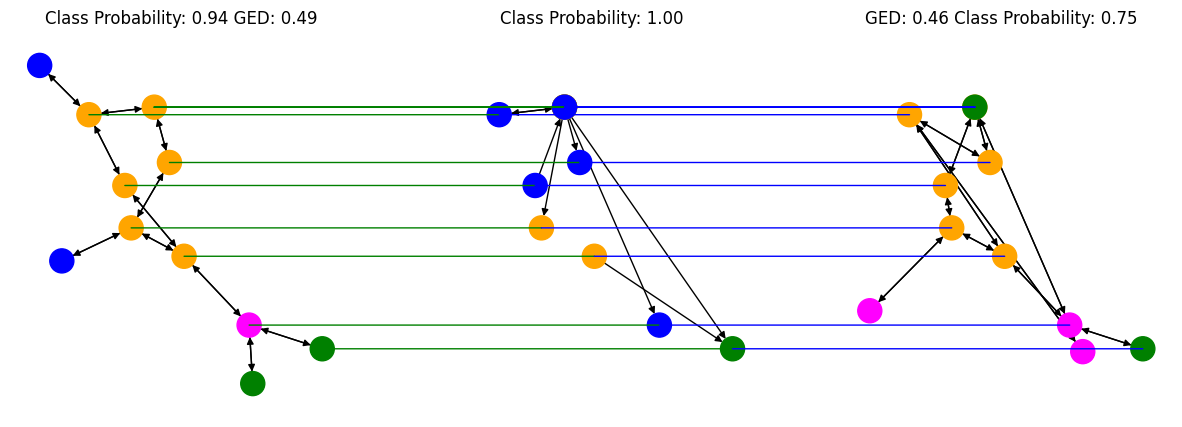

In [25]:
vis_con_graph(
    gen_gnnInt_0_dropped, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Multi-Layer Embedding Similarity

In [26]:
gen_gnnInt_1_ml = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.0281262796165247 SD: 0.025014969467934297
(0.0266, 0.0297)
Baseline % GED to 1
Mean 0.08838704547711781 SD: 0.0017794346228794011
(0.0867, 0.09)
Baseline % GED to 0
Mean 0.07201279451449712 SD: 0.005644167602845808
(0.0661, 0.0779)
Epoch: 0 Losses:[2.1473171819340098, -0.2380701249296015, 11397.657115589489, 2.5854583328420464]
Epoch: 1 Losses:[1.5803088708357378, -0.778249052437869, 1870.7414994673295, 2.7215319004925815]
Epoch: 2 Losses:[1.2843621969223022, -1.1194474534554915, 651.3432339754971, 2.7773625200445]
Epoch: 3 Losses:[1.210394398732619, -1.1820668198845603, 246.79248046875, 2.7599902857433665]
Epoch: 4 Losses:[1.0750284465876492, -1.367835131558505, 107.15669597278942, 2.819389668377963]
Epoch: 5 Losses:[0.955503908070651, -1.493550419807434, 47.01264624162154, 2.7108021541075273]
Epoch: 6 Losses:[0.9037142937833612, -1.558522484519265, 21.007031874223188, 2.7640771811658684]
Epoch: 7 Losses:[0.8465288227254694, -1.624009977687489, 10

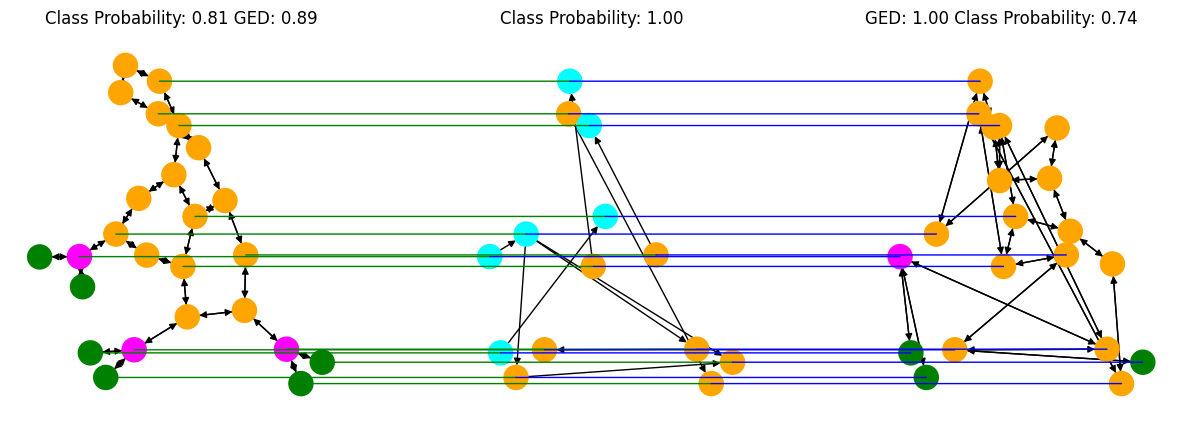

In [27]:
vis_con_graph(
    gen_gnnInt_1_ml, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [28]:
gen_gnnInt_0_ml = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.8495966402888298 SD: 0.07341807897981134
(0.845, 0.8542)
Baseline % GED to 1
Mean 0.08626002286161695 SD: 0.002921170180887864
(0.0836, 0.089)
Baseline % GED to 0
Mean 0.07126722857356071 SD: 0.004352116578333231
(0.0667, 0.0758)
Epoch: 0 Losses:[0.8252938498150219, -1.7330353476784446, 12304.745716441761, -2.688563574444164]
Epoch: 1 Losses:[0.7153650468046014, -1.8486001925034956, 2024.8675315163352, -2.8407399871132593]
Epoch: 2 Losses:[0.7015087116848339, -1.846438310363076, 636.4301286177201, -2.796346577731046]
Epoch: 3 Losses:[0.7143238078464161, -1.8143178224563599, 245.0344099564986, -2.7948468056592075]
Epoch: 4 Losses:[0.6745904142206366, -1.8406117070804944, 104.92473602294922, -2.8000771674242886]
Epoch: 5 Losses:[0.6609011346643622, -1.8541574586521496, 47.40710241144354, -2.789627855474299]
Epoch: 6 Losses:[0.6486022580753673, -1.8405110944401135, 22.748289108276367, -2.8179323239759966]
Epoch: 7 Losses:[0.6750811013308439, -1.799134

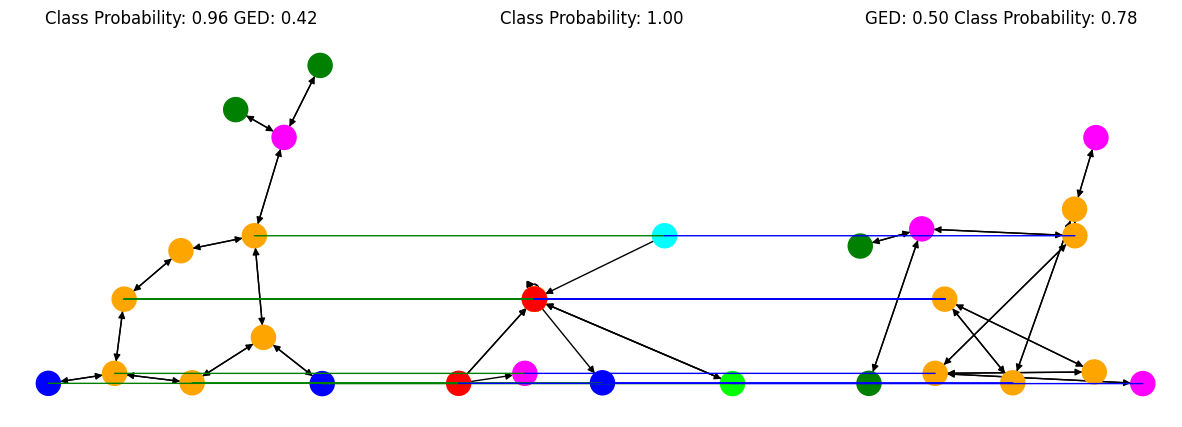

In [29]:
vis_con_graph(
    gen_gnnInt_0_ml,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [30]:
gen_gnnInt_1_dropped_ml = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.0004011885613185768 SD: 0.0011080905172620547
(0.0003, 0.0005)
Baseline % GED to 1
Mean 0.08092539118868965 SD: 0.0035449358115721523
(0.0776, 0.0842)
Baseline % GED to 0
Mean 0.06560899938146274 SD: 0.005178029652669372
(0.0602, 0.071)
Epoch: 0 Losses:[2.349337339401245, -0.06419116529551419, 12535.546209161932, 2.5036207058212976]
Epoch: 1 Losses:[2.2077540917830034, -0.05789026347073642, 2066.579012784091, 2.511948130347512]
Epoch: 2 Losses:[1.9708315242420544, -0.09274541247974742, 643.779316295277, 2.3169991048899563]
Epoch: 3 Losses:[1.5639977780255405, -0.411369957707145, 239.8309881036932, 2.3031008622863074]
Epoch: 4 Losses:[1.1281030719930476, -0.8861735192212191, 99.48967950994319, 2.294007355516607]
Epoch: 5 Losses:[1.0932182290337302, -0.9043928168036721, 43.04209449074485, 2.256201922893524]
Epoch: 6 Losses:[0.8567524118856951, -1.2240529168735852, 20.087279059670188, 2.264583544297652]
Epoch: 7 Losses:[0.7948696613311768, -1.33934457

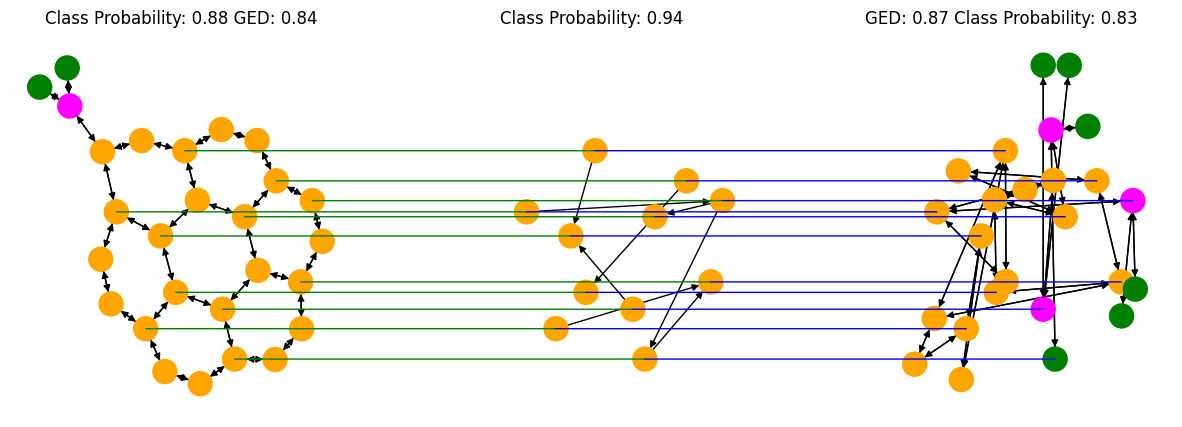

In [31]:
vis_con_graph(
    gen_gnnInt_1_dropped_ml, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [32]:
gen_gnnInt_0_dropped_ml = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.958586744606495 SD: 0.0257668292990593
(0.957, 0.9602)
Baseline % GED to 1
Mean 0.07506663352251053 SD: 0.0020414027398757344
(0.0738, 0.0764)
Baseline % GED to 0
Mean 0.06591060260931651 SD: 0.0012984034185972097
(0.0627, 0.0691)
Epoch: 0 Losses:[0.5477585711262443, -1.8541429367932407, 11928.357044566761, -2.218492399562489]
Epoch: 1 Losses:[0.4721630025993694, -1.8541047898205845, 1877.9445856267755, -2.22988839041103]
Epoch: 2 Losses:[0.45492807030677795, -1.8165818452835083, 582.0688726251775, -2.2794549573551524]
Epoch: 3 Losses:[0.4692300720648332, -1.7875992818312212, 217.63316761363637, -2.2890179644931448]
Epoch: 4 Losses:[0.46613135121085425, -1.794583342292092, 90.10934101451527, -2.318171647461978]
Epoch: 5 Losses:[0.4732912643389268, -1.792788939042525, 39.855727282437414, -2.292013016614047]
Epoch: 6 Losses:[0.500867946581407, -1.7523107203570278, 18.39830103787509, -2.3179241202094336]
Epoch: 7 Losses:[0.4978100657463074, -1.7630865

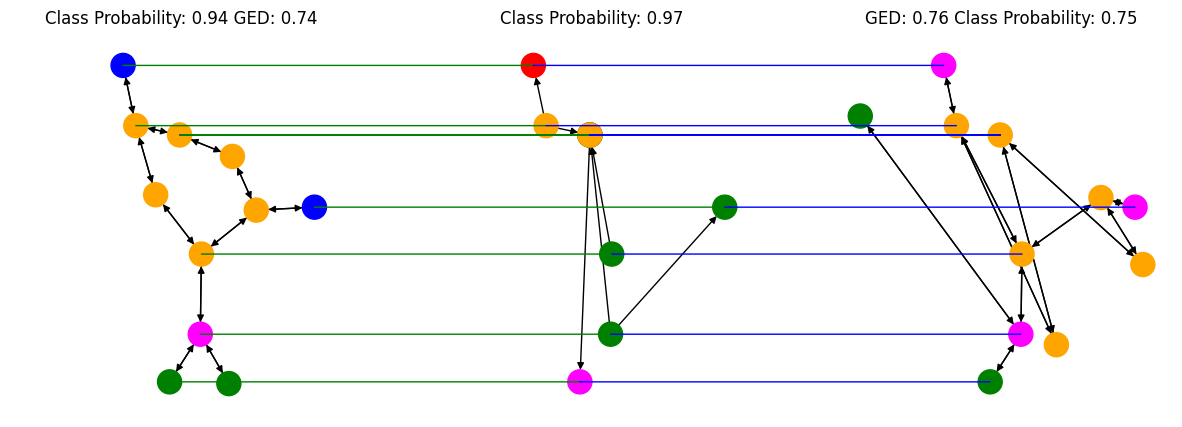

In [33]:
vis_con_graph(
    gen_gnnInt_0_dropped_ml, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Opposing Class Embeddings

In [34]:
gen_gnnInt_1_oc = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.06661711678572464 SD: 0.04369007878038297
(0.0639, 0.0693)
Baseline % GED to 1
Mean 0.09096203531537737 SD: 0.0025484661488288517
(0.0886, 0.0933)
Baseline % GED to 0
Mean 0.07463338350256284 SD: 0.004544347238660249
(0.0699, 0.0794)
Epoch: 0 Losses:[1.923313931985335, -0.5109030441804365, 11089.296275745739, 2.7003752264109524]
Epoch: 1 Losses:[1.307996543970975, -0.774506769397042, 2388.4929643110795, 2.865298043597828]
Epoch: 2 Losses:[1.1878416700796648, -0.8722470294345509, 864.2052529074929, 2.9305989633906973]
Epoch: 3 Losses:[0.9735478379509666, -0.9873274998231367, 318.4902066317472, 2.9389992627230557]
Epoch: 4 Losses:[0.9648773995312777, -0.9981091726909984, 123.111459905451, 2.940339131788774]
Epoch: 5 Losses:[0.8693141341209412, -1.0597033175555142, 51.08837405118075, 2.9832774725827305]
Epoch: 6 Losses:[0.9027681946754456, -1.0613574927503413, 22.667220375754617, 3.0794261910698633]
Epoch: 7 Losses:[0.8748162226243452, -1.081975384192

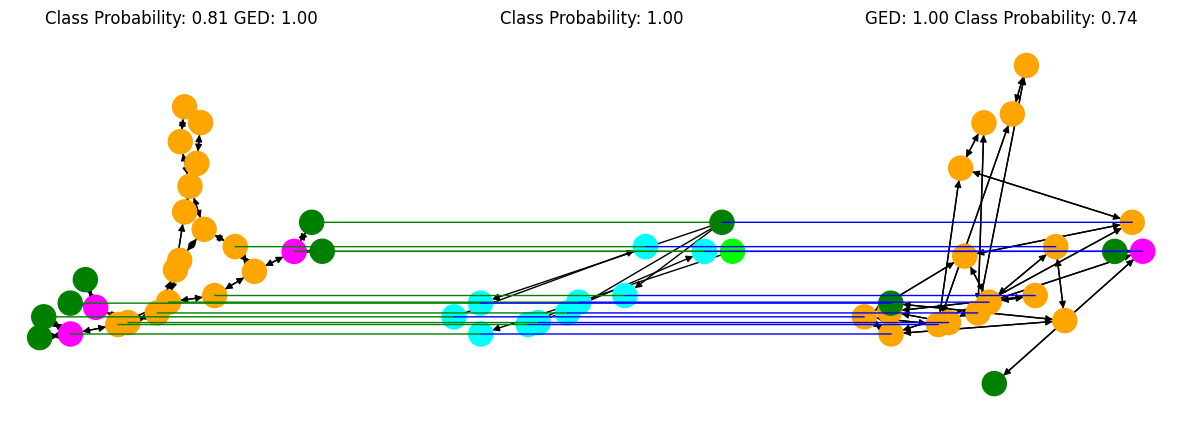

In [35]:
vis_con_graph(
    gen_gnnInt_1_oc, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [36]:
gen_gnnInt_0_oc = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.9456434378623962 SD: 0.037703890541255794
(0.9433, 0.948)
Baseline % GED to 1
Mean 0.08040300863129753 SD: 0.0017567167105697855
(0.0788, 0.082)
Baseline % GED to 0
Mean 0.06499081042905648 SD: 0.004963542744949672
(0.0598, 0.0702)
Epoch: 0 Losses:[0.7133886380629106, -1.1333220330151645, 14497.449440696022, -2.664610266685486]
Epoch: 1 Losses:[0.7063923261382363, -1.1679096221923828, 2471.4726118607955, -2.8142000545154917]
Epoch: 2 Losses:[0.7195380438457836, -1.1621785705739802, 774.0691639293324, -2.8693537495353003]
Epoch: 3 Losses:[0.7400115728378296, -1.1971266594800083, 286.6827572909269, -2.920790921558033]
Epoch: 4 Losses:[0.7470716292207892, -1.2018648711117832, 117.37164861505681, -2.978898297656666]
Epoch: 5 Losses:[0.7551634961908514, -1.2057385119524868, 51.75772614912553, -2.9615562937476416]
Epoch: 6 Losses:[0.7549607699567621, -1.2126140919598667, 24.1500977602872, -3.0291232629255815]
Epoch: 7 Losses:[0.7645456086505543, -1.22026

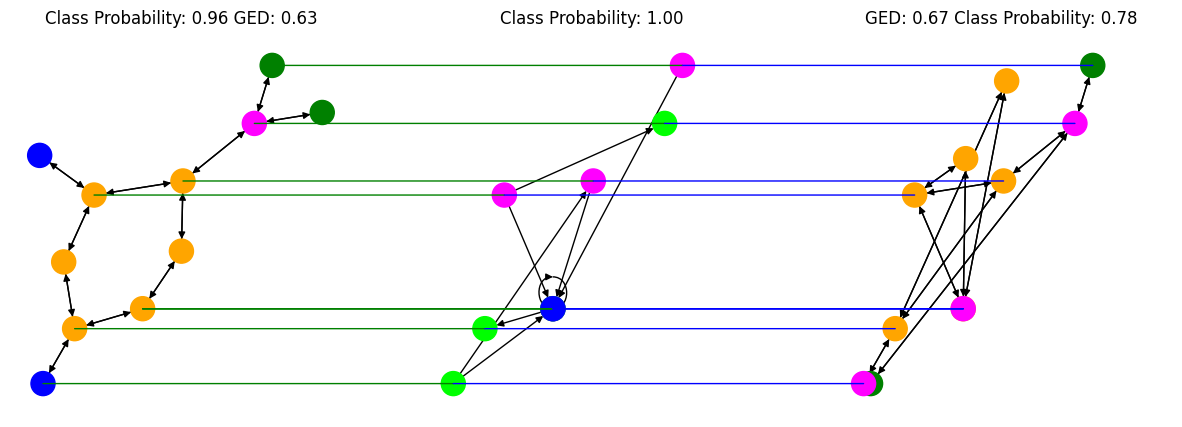

In [37]:
vis_con_graph(
    gen_gnnInt_0_oc,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [38]:
gen_gnnInt_1_dropped_oc = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.0028219506181412727 SD: 0.004796335875527928
(0.0025, 0.0031)
Baseline % GED to 1
Mean 0.07980279092277799 SD: 0.0012578069824008616
(0.0786, 0.081)
Baseline % GED to 0
Mean 0.06606530336042245 SD: 0.005370762665499187
(0.0604, 0.0717)
Epoch: 0 Losses:[2.3318703174591064, -0.22283764589916577, 11653.734752308239, 2.437421901659532]
Epoch: 1 Losses:[2.199737873944369, -0.15118756754831833, 1865.3970281427557, 2.3438846956599844]
Epoch: 2 Losses:[1.8944726532155818, -0.13849134743213654, 588.6510536887429, 2.3574580658565867]
Epoch: 3 Losses:[1.4126129042018543, -0.3243782154538415, 236.41825034401634, 2.187837215987119]
Epoch: 4 Losses:[1.1125569289380854, -0.4776109457015991, 111.03940998424183, 2.2667201974175195]
Epoch: 5 Losses:[0.8560855984687805, -0.6768566153266213, 50.57703191583807, 2.1889285336841238]
Epoch: 6 Losses:[0.8113205324519764, -0.7062126669016752, 22.966779708862305, 2.1436279036782007]
Epoch: 7 Losses:[0.7365683696486733, -0.76

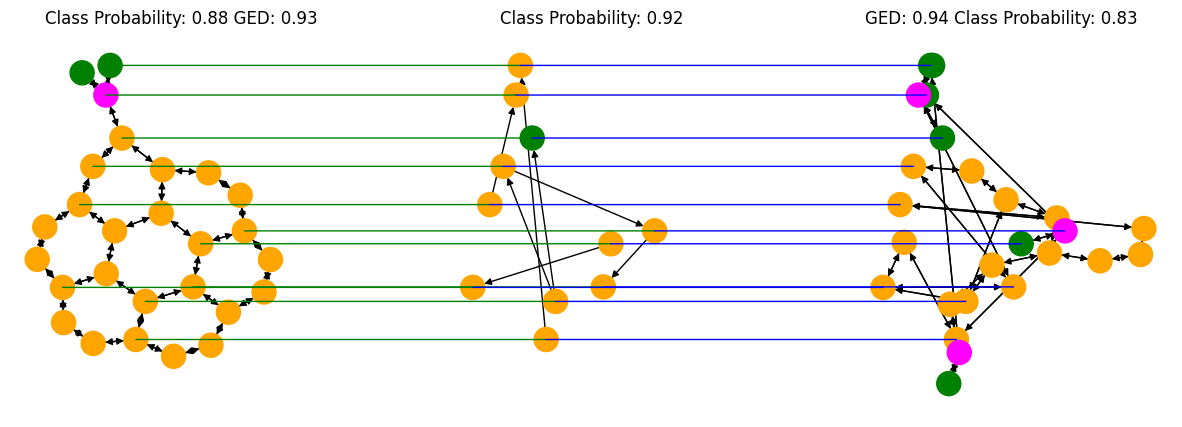

In [39]:
vis_con_graph(
    gen_gnnInt_1_dropped_oc, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [40]:
gen_gnnInt_0_dropped_oc = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.9697896282672882 SD: 0.020705525158854255
(0.9685, 0.9711)
Baseline % GED to 1
Mean 0.08085111963252227 SD: 0.0016516230749916404
(0.0798, 0.0819)
Baseline % GED to 0
Mean 0.06850820779800415 SD: 0.0013816884290643013
(0.0651, 0.0719)
Epoch: 0 Losses:[0.6086978207934987, -1.1129512895237317, 11737.380260120739, -2.695114330811934]
Epoch: 1 Losses:[0.6269628243012861, -1.1384874907406894, 1878.1350929953835, -2.8955669728192417]
Epoch: 2 Losses:[0.6320165395736694, -1.1451174020767212, 568.7229697487571, -2.97640323638916]
Epoch: 3 Losses:[0.6427308158441023, -1.157478007403287, 206.17496837269175, -3.0131289850581777]
Epoch: 4 Losses:[0.6421403559771451, -1.1573234037919478, 84.17499160766602, -2.996548826044256]
Epoch: 5 Losses:[0.6409606825221669, -1.156764268875122, 36.55091736533425, -3.0756259614771064]
Epoch: 6 Losses:[0.6451904611154036, -1.1608032963492654, 16.577982902526855, -3.091184626926075]
Epoch: 7 Losses:[0.649370090527968, -1.16455

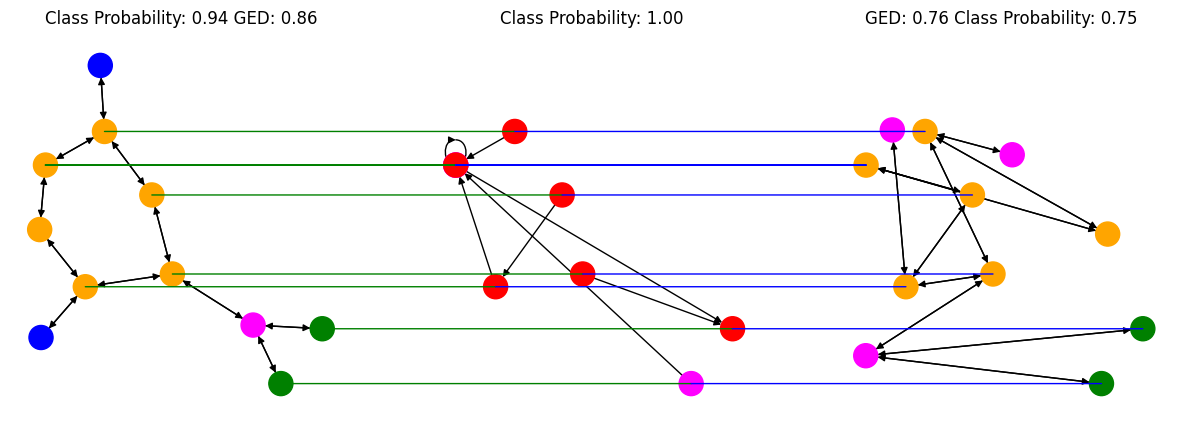

In [41]:
vis_con_graph(
    gen_gnnInt_0_dropped_oc, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Only GED

In [42]:
gen_gnnInt_1_GED = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-4, 1.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.03978968331590295 SD: 0.03586242363299088
(0.0376, 0.042)
Baseline % GED to 1
Mean 0.08454917371273041 SD: 0.0014255359353597702
(0.0832, 0.0859)
Baseline % GED to 0
Mean 0.07238859310746193 SD: 0.0045788784668800075
(0.0676, 0.0772)
Epoch: 0 Losses:[2.3324967080896553, -0.3610736673528498, 14079.09676846591, 2.4062118638645518]
Epoch: 1 Losses:[2.2080247185446997, -0.30400494824756275, 3164.5207963423295, 2.2854940511963586]
Epoch: 2 Losses:[2.0703349872068926, -0.2722430906512521, 1424.0432794744318, 2.0501076877117157]
Epoch: 3 Losses:[1.911814201961864, -0.2485630823807283, 835.7054332386364, 1.8866708061911843]
Epoch: 4 Losses:[1.8643154447728938, -0.23886305364695462, 553.2084822221236, 1.7977754202756016]
Epoch: 5 Losses:[1.6979687105525623, -0.25714354623447766, 400.53368585759944, 1.6183109039610082]
Epoch: 6 Losses:[1.6801825978539207, -0.2383454753593965, 324.91439541903407, 1.5242115584286777]
Epoch: 7 Losses:[1.5277928980914028, -0.279

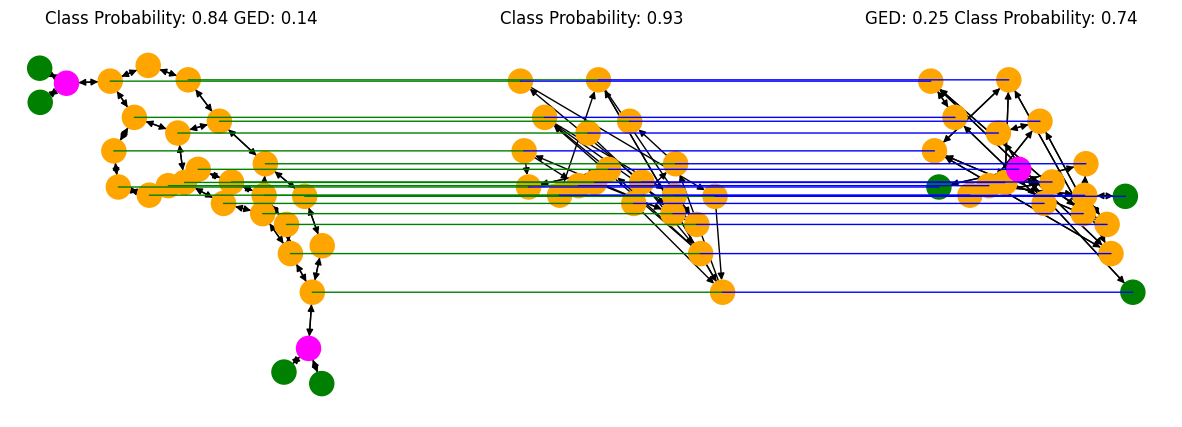

In [43]:
vis_con_graph(
    gen_gnnInt_1_GED, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[3].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [44]:
gen_gnnInt_0_GED = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.8679466738700866 SD: 0.05915346884155403
(0.8643, 0.8716)
Baseline % GED to 1
Mean 0.08474543052060264 SD: 0.0009472327636609383
(0.0839, 0.0856)
Baseline % GED to 0
Mean 0.06913814817865689 SD: 0.0032992550789802803
(0.0657, 0.0726)
Epoch: 0 Losses:[0.8192253004420887, -1.1235070011832498, 15806.719859730114, -2.7435519261793657]
Epoch: 1 Losses:[0.7736954309723594, -1.151229273189198, 4670.095569957386, -2.8375580690123816]
Epoch: 2 Losses:[0.8712089007551019, -1.1165062622590498, 2398.863136985085, -2.883041674440557]
Epoch: 3 Losses:[0.7970429442145608, -1.1441830071535977, 1379.0978005149148, -2.9192722493951972]
Epoch: 4 Losses:[0.7986872087825428, -1.1513840718702837, 854.7077803178267, -2.9339553767984565]
Epoch: 5 Losses:[0.8046285672621294, -1.1376579349691218, 520.2555874911221, -2.9363150271502407]
Epoch: 6 Losses:[0.7826420773159374, -1.1610953699458728, 305.68226346102625, -2.9313540025190874]
Epoch: 7 Losses:[0.8201554959470575, -1.1

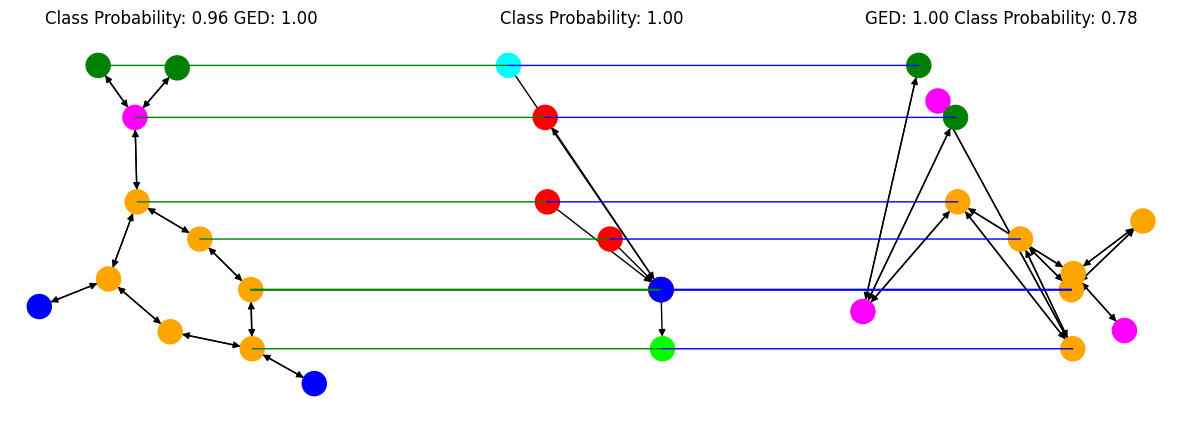

In [45]:
vis_con_graph(
    gen_gnnInt_0_GED,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [46]:
gen_gnnInt_1_dropped_GED = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.010297239501058358 SD: 0.009981487109867591
(0.0097, 0.0109)
Baseline % GED to 1
Mean 0.07875758622373853 SD: 0.00143027127259131
(0.0774, 0.0801)
Baseline % GED to 0
Mean 0.06656499579548836 SD: 0.00447062279148764
(0.0619, 0.0713)
Epoch: 0 Losses:[2.282177058133212, -0.1941191770813682, 17840.635298295456, 2.014647462151267]
Epoch: 1 Losses:[2.191782756285234, -0.13348725302652878, 12873.869318181818, 1.7268909811973572]
Epoch: 2 Losses:[2.1249110481955786, -0.10933430967005817, 12354.57608309659, 1.4978928836909207]
Epoch: 3 Losses:[2.0267353491349653, -0.11075576801191676, 12390.90225497159, 1.323098366910761]
Epoch: 4 Losses:[1.9283836538141423, -0.13127932291139255, 12360.02139559659, 1.2736807275902142]
Epoch: 5 Losses:[1.8489722230217673, -0.1513568250970407, 12302.93856534091, 1.1964180686257102]
Epoch: 6 Losses:[1.7781805883754382, -0.1840867345983332, 12508.91708096591, 1.1123213551261208]
Epoch: 7 Losses:[1.5740902748974888, -0.27277451

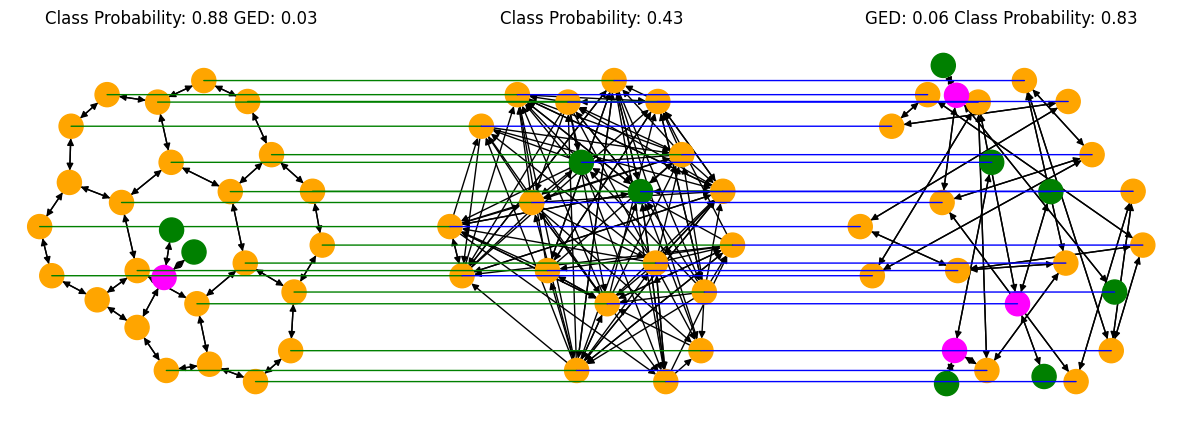

In [47]:
vis_con_graph(
    gen_gnnInt_1_dropped_GED, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [48]:
gen_gnnInt_0_dropped_GED = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.9992888386249542 SD: 0.0017201705489941314
(0.9992, 0.9994)
Baseline % GED to 1
Mean 0.08451763975123565 SD: 0.0018875851645948438
(0.0833, 0.0857)
Baseline % GED to 0
Mean 0.06991733858982722 SD: 0.001958953826220378
(0.0651, 0.0748)
Epoch: 0 Losses:[0.6444823308424517, -1.1563098647377708, 13401.894841974432, -2.7850938114252957]
Epoch: 1 Losses:[0.6674736142158508, -1.1800563877279109, 3699.273770419034, -3.018283345482566]
Epoch: 2 Losses:[0.6792384060946378, -1.1917950131676414, 1865.4505060369318, -3.0788088061592798]
Epoch: 3 Losses:[0.6810980385000055, -1.1922628662802957, 1026.1961836381392, -3.15735463662581]
Epoch: 4 Losses:[0.6879097602584145, -1.1984619118950584, 579.1856134588069, -3.1109316023913296]
Epoch: 5 Losses:[0.6934209357608448, -1.2030776305632158, 331.9055897105824, -3.1658723679455845]
Epoch: 6 Losses:[0.6975133744153109, -1.205574870109558, 197.00818564675072, -3.171626091003418]
Epoch: 7 Losses:[0.6978994933041659, -1.20

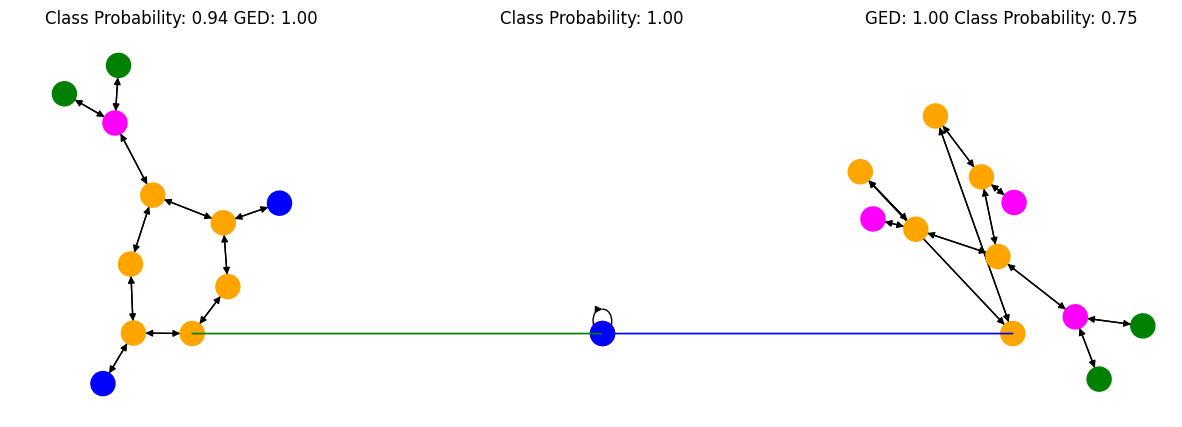

In [49]:
vis_con_graph(
    gen_gnnInt_0_dropped_GED, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Full Loss

In [50]:
gen_gnnInt_1_full = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.01677913216155139 SD: 0.020347066872843673
(0.0155, 0.018)
Baseline % GED to 1
Mean 0.08001479825803212 SD: 0.0014819242161643448
(0.0786, 0.0814)
Baseline % GED to 0
Mean 0.0663718730211258 SD: 0.005229777364111495
(0.0609, 0.0719)
Epoch: 0 Losses:[2.1454882513393057, -0.4053517959334634, 22006.864524147728, 2.1909344873645087]
Epoch: 1 Losses:[1.5573215051130815, -0.5590078288858588, 15641.432084517046, 2.0194593397053806]
Epoch: 2 Losses:[1.0279501730745488, -0.8206319429657676, 14773.20987215909, 1.9719804742119529]
Epoch: 3 Losses:[0.8385831930420615, -0.9606062390587546, 14148.696466619318, 1.9280715774406085]
Epoch: 4 Losses:[0.7547378269108859, -1.0014656457034024, 13753.228160511364, 1.787566970695149]
Epoch: 5 Losses:[0.7136608849872242, -1.0296692956577649, 13518.104048295454, 1.7450734864581714]
Epoch: 6 Losses:[0.6852458715438843, -1.0471201809969815, 13456.499644886364, 1.7163289189338684]
Epoch: 7 Losses:[0.665445864200592, -1.017171

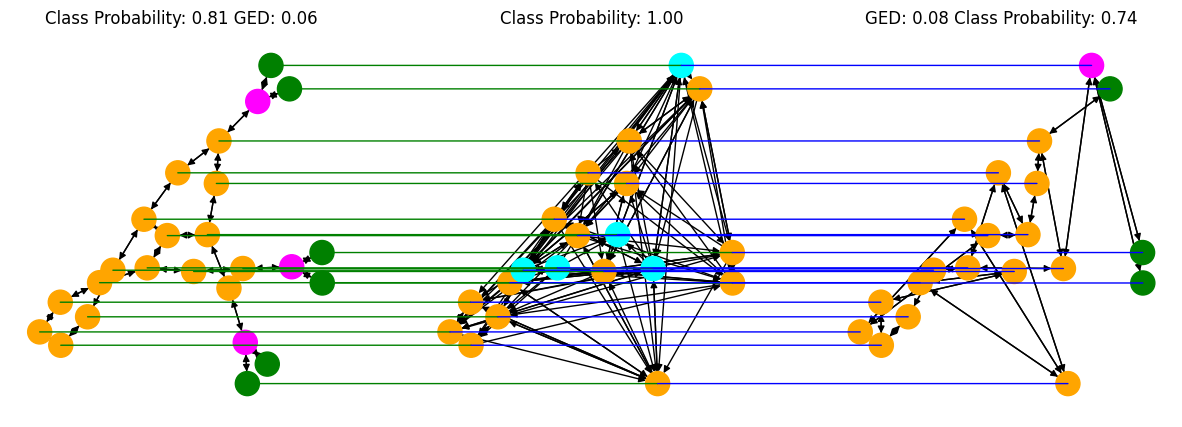

In [51]:
vis_con_graph(
    gen_gnnInt_1_full, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [52]:
gen_gnnInt_0_full = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1e6]), 
)

Baseline Prediction Accuracy: 
Mean 0.9819001525044441 SD: 0.020144559046262413
(0.9807, 0.9832)
Baseline % GED to 1
Mean 0.09439816219466073 SD: 0.001959465545390802
(0.0926, 0.0962)
Baseline % GED to 0
Mean 0.07608436793088913 SD: 0.004326644571687395
(0.0715, 0.0806)
Epoch: 0 Losses:[0.7390129241076383, -1.1826067512685603, 23963.135120738636, -2.747720469128002]
Epoch: 1 Losses:[0.7714700373736295, -1.1907736604863948, 14529.56827059659, -2.8750489841807974]
Epoch: 2 Losses:[0.7573374076323076, -1.2059501301158557, 10677.646750710228, -2.920536377213218]
Epoch: 3 Losses:[0.7576090043241327, -1.2066178755326704, 8075.189586292614, -2.8842500773343174]
Epoch: 4 Losses:[0.7669583775780418, -1.2128210717981511, 6346.75244140625, -2.9073634147644043]
Epoch: 5 Losses:[0.7612952319058505, -1.2181974541057239, 4956.637428977273, -2.9143302115527066]
Epoch: 6 Losses:[0.772794631394473, -1.2187990925528787, 3987.168301669034, -2.948681527918035]
Epoch: 7 Losses:[0.7702562375502153, -1.229483

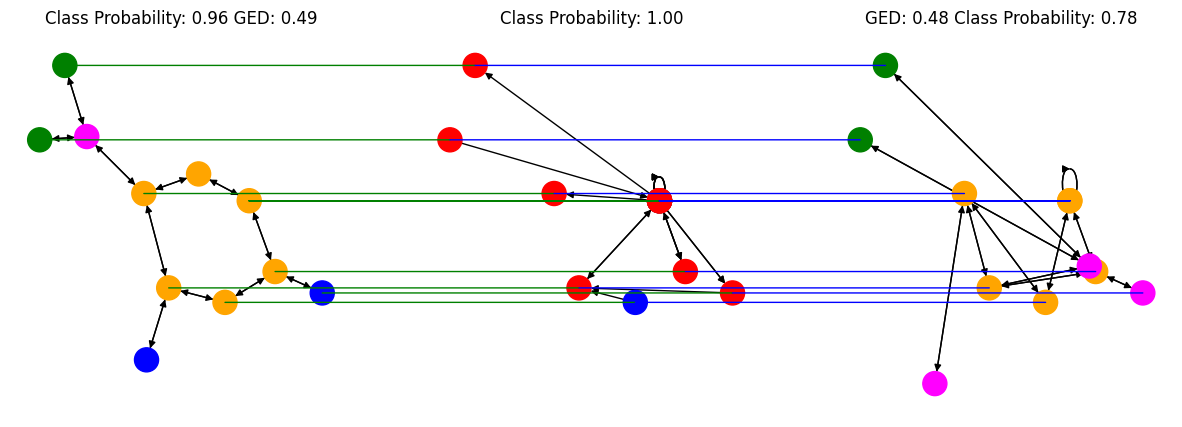

In [53]:
vis_con_graph(
    gen_gnnInt_0_full,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [54]:
gen_gnnInt_1_dropped_full = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1.0]), 
    epochs=25
)

Baseline Prediction Accuracy: 
Mean 0.004002052678224573 SD: 0.005212078715870585
(0.0037, 0.0043)
Baseline % GED to 1
Mean 0.07458696301494326 SD: 0.0018932822257862135
(0.0728, 0.0763)
Baseline % GED to 0
Mean 0.06091215771933397 SD: 0.003994207397301082
(0.0567, 0.0651)
Epoch: 0 Losses:[2.3483529957858, -0.2427675493738868, 23197.501420454544, 2.2042082873257725]
Epoch: 1 Losses:[2.2797006260265005, -0.1980092390017076, 15240.250621448864, 1.8952420245517383]
Epoch: 2 Losses:[2.178979288447987, -0.1376527859406038, 14036.21590909091, 1.5843670964241028]
Epoch: 3 Losses:[2.1095341552387583, -0.11301203275268729, 13786.462890625, 1.452468823302876]
Epoch: 4 Losses:[2.0050665356896142, -0.10493435575203462, 13825.393288352272, 1.3075203407894482]
Epoch: 5 Losses:[1.8350727666508069, -0.1573289077390324, 13772.817915482954, 1.2647387439554387]
Epoch: 6 Losses:[1.5602952350269665, -0.2604233825748617, 13748.524857954546, 1.1536821560426191]
Epoch: 7 Losses:[1.2582359422336926, -0.4248093

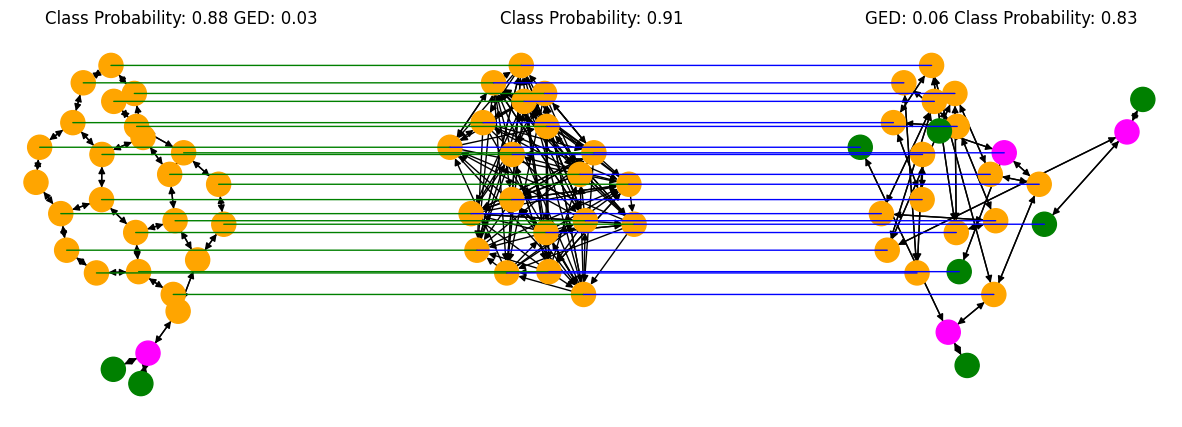

In [55]:
vis_con_graph(
    gen_gnnInt_1_dropped_full, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [56]:
gen_gnnInt_0_dropped_full = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.9900019415020943 SD: 0.010441380297226197
(0.9894, 0.9906)
Baseline % GED to 1
Mean 0.08147137674192588 SD: 0.0029370210664533256
(0.0796, 0.0833)
Baseline % GED to 0
Mean 0.06824448208014171 SD: 0.0002698672870508278
(0.0676, 0.0689)
Epoch: 0 Losses:[0.614976552399722, -1.1272096633911133, 14279.590465198864, -2.7740525169806047]
Epoch: 1 Losses:[0.6336300806565718, -1.147703842683272, 4166.70430131392, -2.9550031315196645]
Epoch: 2 Losses:[0.6417779326438904, -1.1564449613744563, 1967.1441872336648, -3.058488889174028]
Epoch: 3 Losses:[0.648463249206543, -1.163159435445612, 1088.7226839932528, -3.04123469916257]
Epoch: 4 Losses:[0.6503294056112116, -1.1645614342256025, 606.1567327325994, -3.1184827306053857]
Epoch: 5 Losses:[0.6561535163359209, -1.170621861111034, 358.1257240988991, -3.128433726050637]
Epoch: 6 Losses:[0.6571442539041693, -1.1707645546306262, 208.70029518821022, -3.1288315707987007]
Epoch: 7 Losses:[0.6601972850886259, -1.1738926

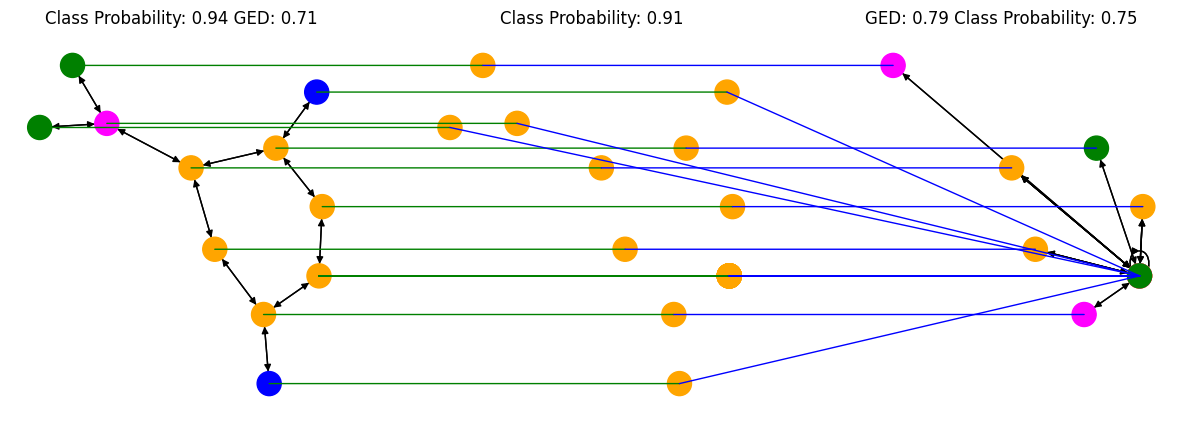

In [57]:
vis_con_graph(
    gen_gnnInt_0_dropped_full, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Parameter Distribution

In [58]:
data_0 = train_data_list_0 + test_data_list_0
data_1 = train_data_list_1 + test_data_list_1

batch_0 = pyg.data.Batch.from_data_list(data_0)
batch_1 = pyg.data.Batch.from_data_list(data_1)

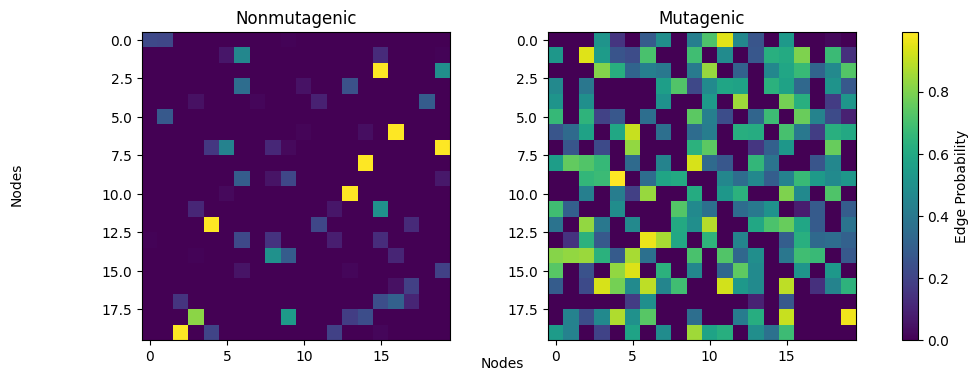

In [59]:
edge_probs_0 = gen_gnnInt_0_full.AdjacencyMatrix.probs
edge_probs_0 = edge_probs_0.detach().cpu().numpy()

edge_probs_1 = gen_gnnInt_1_full.AdjacencyMatrix.probs
edge_probs_1 = edge_probs_1.detach().cpu().numpy()

# edge_probs_untrained = generator_untrained.AdjacencyMatrix.probs
# edge_probs_untrained = edge_probs_untrained.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(edge_probs_0, cmap='viridis', interpolation='nearest')
im1 = axes[1].imshow(edge_probs_1, cmap='viridis', interpolation='nearest')
#im2 = axes[2].imshow(edge_probs_untrained, cmap='viridis', interpolation='nearest')

# Add a common color bar
cbar = fig.colorbar(im1, ax=axes.ravel().tolist())
cbar.set_label('Edge Probability')

# Set titles
axes[0].set_title('Nonmutagenic')
axes[1].set_title('Mutagenic')
# axes[2].set_title('Untrained')

# Set common x and y labels
fig.text(0.45, 0.04, 'Nodes', ha='center')
fig.text(0.04, 0.5, 'Nodes', va='center', rotation='vertical')

plt.show()

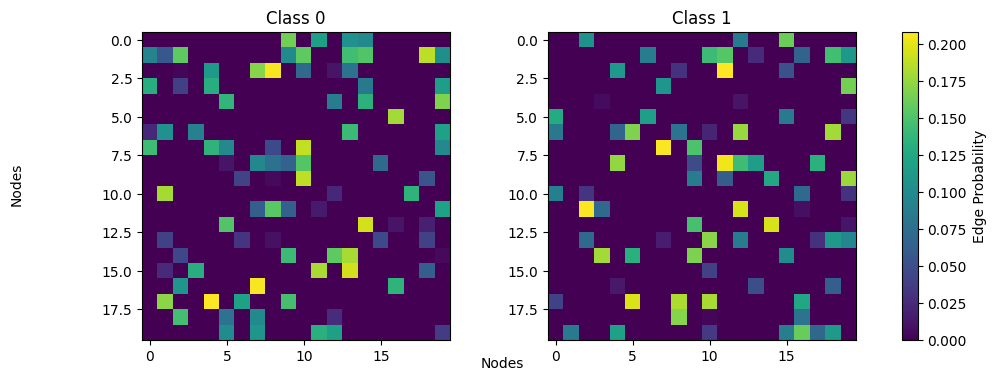

In [60]:
edge_probs_0 = gen_gnnInt_0_oc.AdjacencyMatrix.probs
edge_probs_0 = edge_probs_0.detach().cpu().numpy()

edge_probs_1 = gen_gnnInt_1_oc.AdjacencyMatrix.probs
edge_probs_1 = edge_probs_1.detach().cpu().numpy()

# edge_probs_untrained = generator_untrained.AdjacencyMatrix.probs
# edge_probs_untrained = edge_probs_untrained.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(edge_probs_0, cmap='viridis', interpolation='nearest')
im1 = axes[1].imshow(edge_probs_1, cmap='viridis', interpolation='nearest')
#im2 = axes[2].imshow(edge_probs_untrained, cmap='viridis', interpolation='nearest')

# Add a common color bar
cbar = fig.colorbar(im1, ax=axes.ravel().tolist())
cbar.set_label('Edge Probability')

# Set titles
axes[0].set_title('Class 0')
axes[1].set_title('Class 1')
# axes[2].set_title('Untrained')

# Set common x and y labels
fig.text(0.45, 0.04, 'Nodes', ha='center')
fig.text(0.04, 0.5, 'Nodes', va='center', rotation='vertical')

plt.show()

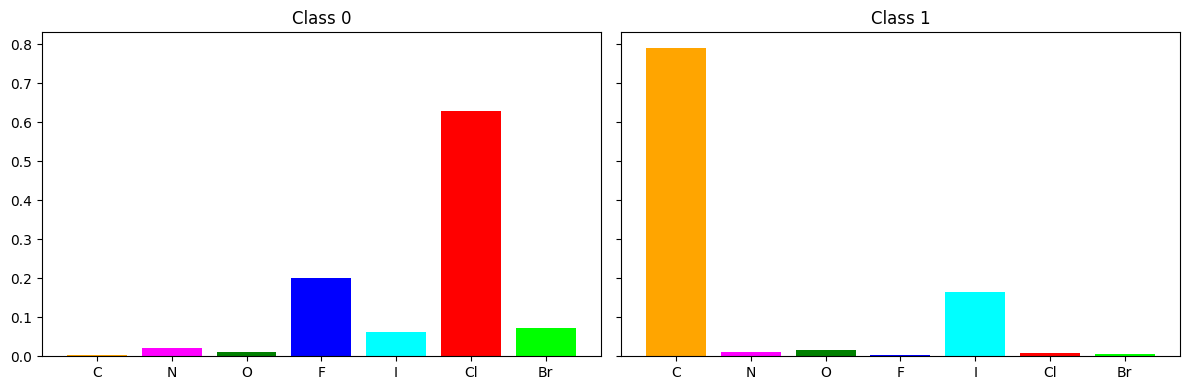

In [61]:
cell_type_probs_0 = torch.softmax(gen_gnnInt_0_full.DisNodeFeats[0].probs, dim=0)
cell_type_probs_0 = cell_type_probs_0.detach().cpu().numpy()

cell_type_probs_1 = torch.softmax(gen_gnnInt_1_full.DisNodeFeats[0].probs, dim=0)
cell_type_probs_1 = cell_type_probs_1.detach().cpu().numpy()

# cell_type_probs_untrained = torch.softmax(
#     generator_untrained.DisNodeFeats[0].probs, dim=0)
# cell_type_probs_untrained = cell_type_probs_untrained.detach().cpu().numpy()

plot_indices = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']
edge_types = ['aromatic', 'single', 'double', 'triple']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(plot_indices, cell_type_probs_0, color=color_palette)
axes[1].bar(plot_indices, cell_type_probs_1, color=color_palette)
#axes[2].bar(plot_indices, cell_type_probs_untrained, color=color_palette)

axes[0].set_title('Class 0')
axes[1].set_title('Class 1')
#axes[2].set_title('Untrained')

plt.tight_layout()
plt.show()

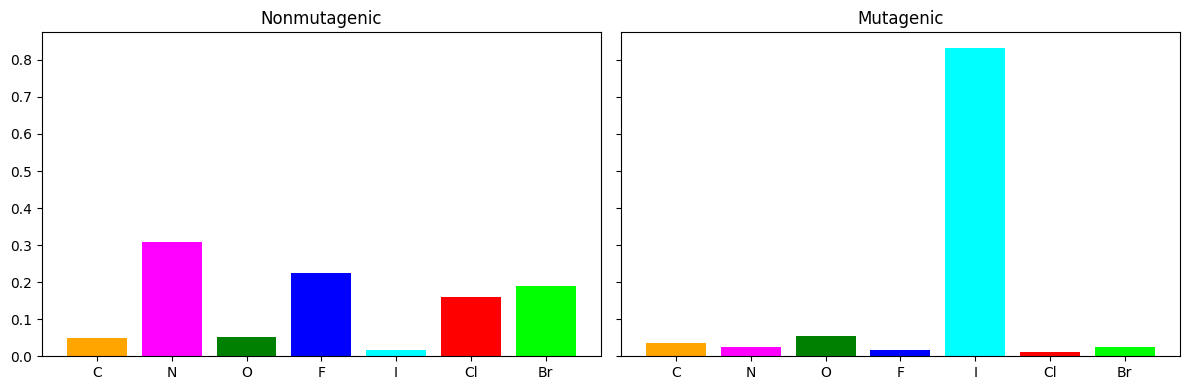

In [62]:
cell_type_probs_0 = torch.softmax(gen_gnnInt_0_oc.DisNodeFeats[0].probs, dim=0)
cell_type_probs_0 = cell_type_probs_0.detach().cpu().numpy()

cell_type_probs_1 = torch.softmax(gen_gnnInt_1_oc.DisNodeFeats[0].probs, dim=0)
cell_type_probs_1 = cell_type_probs_1.detach().cpu().numpy()

# cell_type_probs_untrained = torch.softmax(
#     generator_untrained.DisNodeFeats[0].probs, dim=0)
# cell_type_probs_untrained = cell_type_probs_untrained.detach().cpu().numpy()

plot_indices = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']
edge_types = ['aromatic', 'single', 'double', 'triple']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(plot_indices, cell_type_probs_0, color=color_palette)
axes[1].bar(plot_indices, cell_type_probs_1, color=color_palette)
#axes[2].bar(plot_indices, cell_type_probs_untrained, color=color_palette)

axes[0].set_title('Nonmutagenic')
axes[1].set_title('Mutagenic')
#axes[2].set_title('Untrained')

plt.tight_layout()
plt.show()

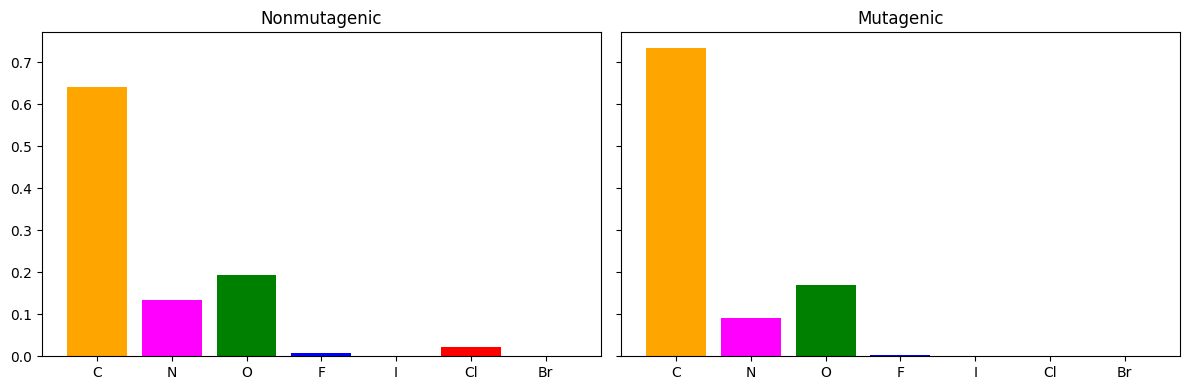

In [63]:
emp_dist_node_0 = batch_0.x.argmax(dim=-1).numpy()
emp_dist_node_1 = batch_1.x.argmax(dim=-1).numpy()

# Empirical node type probabilities
unique_classes_0, counts_0 = np.unique(emp_dist_node_0, return_counts=True)
percentages_0 = (counts_0 / len(emp_dist_node_0))
percentages_0 = np.insert(percentages_0, 4, 0.0) # missing I

unique_classes_1, counts_1 = np.unique(emp_dist_node_1, return_counts=True)
percentages_1 = (counts_1 / len(emp_dist_node_1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

plot_indices = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']

axes[0].bar(plot_indices, percentages_0, color=color_palette)
axes[1].bar(plot_indices, percentages_1, color=color_palette)

axes[0].set_title('Nonmutagenic')
axes[1].set_title('Mutagenic')

plt.tight_layout()
plt.show()

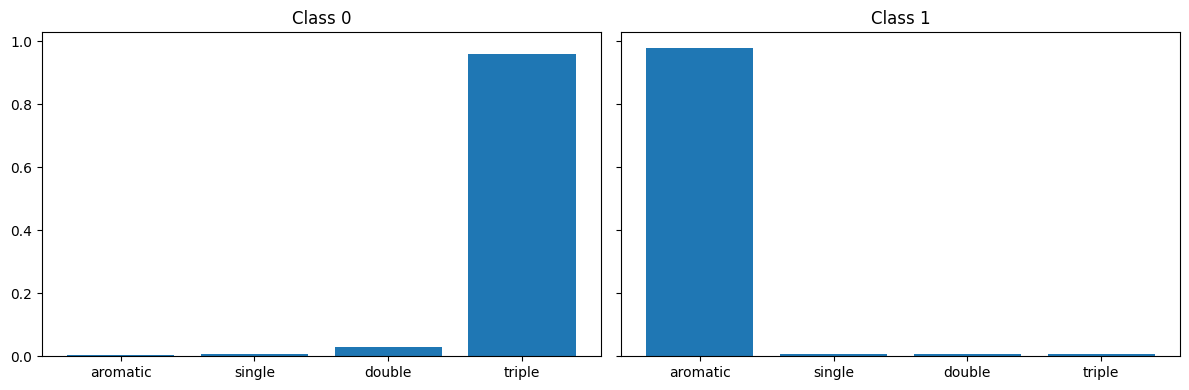

In [64]:
edge_type_probs_0 = torch.softmax(gen_gnnInt_0_full.DisEdgeFeats[0].probs, dim=0)
edge_type_probs_0 = edge_type_probs_0.detach().cpu().numpy()

edge_type_probs_1 = torch.softmax(gen_gnnInt_1_full.DisEdgeFeats[0].probs, dim=0)
edge_type_probs_1 = edge_type_probs_1.detach().cpu().numpy()

# edge_type_probs_untrained = torch.softmax(
#     generator_untrained.DisEdgeFeats[0].probs, dim=0)
# edge_type_probs_untrained = edge_type_probs_untrained.detach().cpu().numpy()

plot_indices = ['aromatic', 'single', 'double', 'triple']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(plot_indices, edge_type_probs_0)
axes[1].bar(plot_indices, edge_type_probs_1)
#axes[2].bar(plot_indices, edge_type_probs_untrained)

axes[0].set_title('Class 0')
axes[1].set_title('Class 1')
#axes[2].set_title('Untrained')

plt.tight_layout()
plt.show()

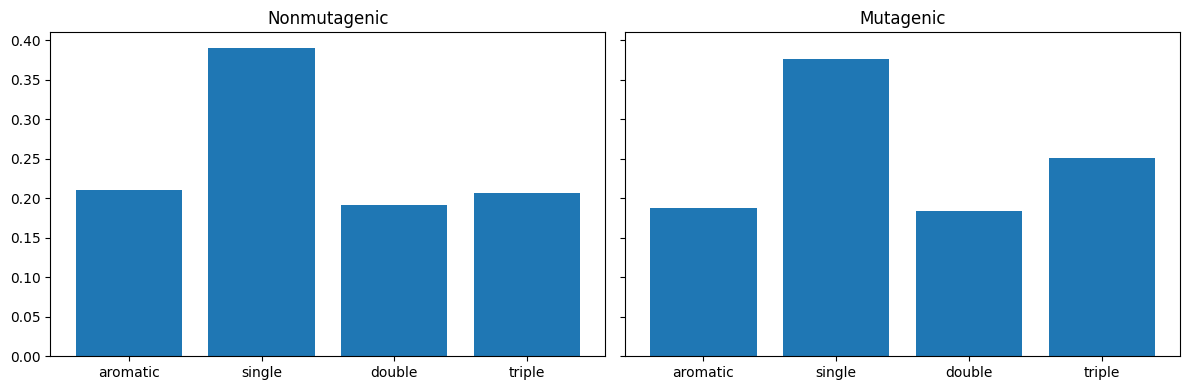

In [65]:
edge_type_probs_0 = torch.softmax(gen_gnnInt_0_oc.DisEdgeFeats[0].probs, dim=0)
edge_type_probs_0 = edge_type_probs_0.detach().cpu().numpy()

edge_type_probs_1 = torch.softmax(gen_gnnInt_1_oc.DisEdgeFeats[0].probs, dim=0)
edge_type_probs_1 = edge_type_probs_1.detach().cpu().numpy()

# edge_type_probs_untrained = torch.softmax(
#     generator_untrained.DisEdgeFeats[0].probs, dim=0)
# edge_type_probs_untrained = edge_type_probs_untrained.detach().cpu().numpy()

plot_indices = ['aromatic', 'single', 'double', 'triple']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(plot_indices, edge_type_probs_0)
axes[1].bar(plot_indices, edge_type_probs_1)
#axes[2].bar(plot_indices, edge_type_probs_untrained)

axes[0].set_title('Nonmutagenic')
axes[1].set_title('Mutagenic')
#axes[2].set_title('Untrained')

plt.tight_layout()
plt.show()

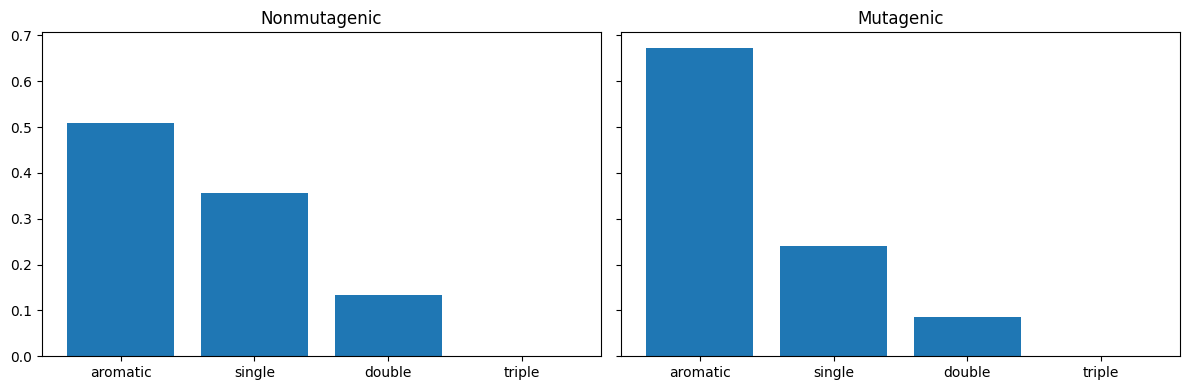

In [66]:
# Empirical edge type probabilities
emp_dist_edge_0 = batch_0.edge_attr.argmax(dim=-1).numpy()
emp_dist_edge_1 = batch_1.edge_attr.argmax(dim=-1).numpy()

unique_classes_0, counts_0 = np.unique(emp_dist_edge_0, return_counts=True)
percentages_0 = (counts_0 / len(emp_dist_edge_0))
percentages_0 = np.insert(percentages_0, 3, 0.0) # no triples. 

unique_classes_1, counts_1 = np.unique(emp_dist_edge_1, return_counts=True)
percentages_1 = (counts_1 / len(emp_dist_edge_1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(edge_types, percentages_0)
axes[1].bar(edge_types, percentages_1)

axes[0].set_title('Nonmutagenic')
axes[1].set_title('Mutagenic')

plt.tight_layout()
plt.show()

### Clean-UP

In [67]:
import gc

# Get all objects in the current context
for obj in gc.get_objects():
    if torch.is_tensor(obj) and obj.is_cuda:
        del obj

# Clear the cache
torch.cuda.empty_cache()

# Optionally synchronize (wait for GPU computations to finish)
torch.cuda.synchronize()

/work/DPDS/s224833/Dissertation/gnn-egg/env/egg-env-38/lib/python3.8/site-packages/torch/distributed/distributed_c10d.py:293: UserWarning: torch.distributed.reduce_op is deprecated, please use torch.distributed.ReduceOp instead
  warnings.warn(
